In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# FaIR analysis of California offsetting

We're interested in understanding how the cooling affect implied by the CO2e metric compares to the actual portfolio of multi-gas emission reductions. We use FaIR to compare temperature outcomes of: 

1. gas-specific offset project emissions reductions versus the "equivalent" CO2 reductions implied by the CO2e metric
2. the offsetting program as a whole (both project fluxes and offset-justified emissions)

inputs:
- ca_project_fluxes.csv
- ca_justified_emissions_fluxes.csv

scenarios:
- baseline: ssp1-2.6 only
- projects_only: ssp126 + credited project fluxes (supply side; physical emissions justified by using offsets)
- emissions_only: ssp126 + offset-justified emissions (demand side; physical project co2, ch4, and ODS fluxes)
- net_program: ssp126 + offset-justified emissions + project fluxes
- claimed_project: baseline + project co2 fluxes + ch4 and ODS project fluxes converted to co2e
- actual_ch4: baseline + physical ch4 project fluxes only
- claimed_ch4: baseline + ch4 project fluxes converted to co2e only
- actual_ods: baseline + physical ODS project fluxes only
- claimed_ods: baseline + ODS project fluxes converted to co2e only

The justified emissions file inlcuded CH4, CO2 and N2O emissions. The project flux file includes CO2, CH4, CFC-11, CFC-12, CFC-113, CFC-114, and CFC-115 separately. FaIR does not include a default CFC-13 configuration, so CFC-13 project fluxes and their associated share of justified emissions are excluded from the gas-specific temperature analysis.

Updated FaIR methodology: The primary analysis uses the 841-member calibrated and constrained FaIR v2.2 ensemble (calibration v1.4.1) under an SSP1-2.6 baseline. Following Hughes et al. (2026), methane lifetime parameters are replaced with their v1.4.0 calibration values because the v1.4.1 methane calibration produces a substantially longer and unrealistic methane lifetime as a result of model calibration to match atmospheric observations. The original default FaIR parameters are kept as a legacy comparison to quantify the effect of the update.

In [11]:
# ----------------------------
# Inputs
# ----------------------------

PROJECTS_FILE = "../timeseries-data/output-data/ca_project_fluxes.csv"
EMISSIONS_FILE = "../timeseries-data/output-data/ca_justified_emissions_fluxes.csv"
# calibration v1.4.1 provides the constrained 841-member climate/carbon-cycle ensemble
FAIR_PARAMS_FILE = "../timeseries-data/input-data/fair/calibrated_constrained_parameters_calibration1.4.1.csv"
# species parameters corresponding to calibration v1.4.1
FAIR_SPECIES_CONFIG_FILE = "../timeseries-data/input-data/fair/species_configs_properties_calibration1.4.1.csv"
# v1.4.0 methane lifetime calibration
CH4_LIFETIME_140 = "../timeseries-data/input-data/fair/CH4_lifetime_calibration1.4.0.csv"
BASELINE_SCENARIO = "ssp126" #Used in Hughes et al., 2026
OLD_BASELINE_SCENARIO = "ssp245"

# Add lifetime and emissions scaling
CH4_BASE_LIFETIME_YR = 8.7 #Baseline is 10.007 yrs
CH4_EMISSIONS_SCALE = 1.2

ODS_COLUMN_TO_SPECIES = {"cfc-11_flux": "CFC-11", "cfc-12_flux": "CFC-12", "cfc-113_flux": "CFC-113", "cfc-114_flux": "CFC-114", "cfc-115_flux": "CFC-115"}
ODS_SPECIES = list(ODS_COLUMN_TO_SPECIES.values())
ODS_COLUMNS = list(ODS_COLUMN_TO_SPECIES.keys())

ODS_GWP20 = {"CFC-11": 6900, "CFC-12": 6900, "CFC-13": 10900, "CFC-113": 6490, "CFC-114": 7710, "CFC-115": 5860}
ODS_GWP100 = {"CFC-11": 4660, "CFC-12": 10200, "CFC-13": 13900, "CFC-113": 5820, "CFC-114": 8590, "CFC-115": 7670}
ODS_GWP500 = {"CFC-11": 1620, "CFC-12": 5200, "CFC-13": 16400, "CFC-113": 2700, "CFC-114": 8730, "CFC-115": 9990}
ODS_GTP20 = {"CFC-11": 6890, "CFC-12": 11300, "CFC-13": 11700, "CFC-113": 6730, "CFC-114": 8190, "CFC-115": 6310}
ODS_GTP50 = {"CFC-11": 4890, "CFC-12": 11000, "CFC-13": 14200, "CFC-113": 6250, "CFC-114": 9020, "CFC-115": 7810}
ODS_GTP100 = {"CFC-11": 2340, "CFC-12": 8450, "CFC-13": 15900, "CFC-113": 4470, "CFC-114": 8550, "CFC-115": 8980}

# year-dependent gwp100 for ch4
def gwp_ch4(year):
    return 21 if year <= 2020 else 25

# gwp100 for cfc-12
gwp_cfc12 = ODS_GWP100["CFC-12"]

In [12]:
# ----------------------------
# load data
# ----------------------------

df_p = pd.read_csv(PROJECTS_FILE)
df_p.columns = df_p.columns.str.lower()
df_p = df_p[["year", "co2_flux", "ch4_flux", "cfc-11_flux", "cfc-12_flux", "cfc-13_flux", "cfc-113_flux", "cfc-114_flux", "cfc-115_flux", "total_credits_used"]].sort_values("year").fillna(0)

df_e = pd.read_csv(EMISSIONS_FILE)
df_e.columns = df_e.columns.str.lower()
df_e = df_e[["year", "co2_justified", "ch4_justified", "n2o_justified"]].sort_values("year").fillna(0)

# remove the share of justified emissions associated with cfc-13 credits, which aren't built into FaIR
cfc13_adjustment = df_p[["year", "cfc-13_flux", "total_credits_used"]].copy()
cfc13_adjustment["cfc13_credits"] = -cfc13_adjustment["cfc-13_flux"].clip(upper=0) * ODS_GWP100["CFC-13"]
cfc13_adjustment["retained_credit_fraction"] = np.where(cfc13_adjustment["total_credits_used"] > 0, 1 - cfc13_adjustment["cfc13_credits"] / cfc13_adjustment["total_credits_used"], 1)
if ((cfc13_adjustment["retained_credit_fraction"] < 0) | (cfc13_adjustment["retained_credit_fraction"] > 1)).any():
    raise ValueError("CFC-13 credit adjustment produced a retained fraction outside [0, 1].")

df_e = df_e.merge(cfc13_adjustment[["year", "retained_credit_fraction"]], on="year", how="left")
df_e["retained_credit_fraction"] = df_e["retained_credit_fraction"].fillna(1)
df_e[["co2_justified", "ch4_justified", "n2o_justified"]] = df_e[["co2_justified", "ch4_justified", "n2o_justified"]].mul(df_e["retained_credit_fraction"], axis=0)
df_e = df_e.drop(columns="retained_credit_fraction")

print("CFC-13-attributable justified emissions removed (tCO2e):", cfc13_adjustment["cfc13_credits"].sum())

CFC-13-attributable justified emissions removed (tCO2e): 10142.315832778115


# Run FaIR simulations

In [13]:
# ----------------------------
# original central FaIR configuration
# retained for comparison with the updated methodology
# ----------------------------

import contextlib
import os

f = FAIR()
f.define_time(1750, 2200, 1)
f.define_scenarios([OLD_BASELINE_SCENARIO, "emissions_only", "projects_only", "net_program", "claimed_project", "actual_co2", "actual_ch4", "claimed_ch4", "actual_ods", "claimed_ods"])
f.define_configs(["central"])

all_species, all_props = read_properties()

species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES, "CO2"]
properties = {s: all_props[s] for s in species}

properties["CO2 FFI"]["input_mode"] = "emissions"
properties["CO2 FFI"]["greenhouse_gas"] = False

properties["CO2 AFOLU"]["input_mode"] = "emissions"
properties["CO2 AFOLU"]["greenhouse_gas"] = False

properties["CH4"]["input_mode"] = "emissions"
properties["CH4"]["greenhouse_gas"] = True

properties["N2O"]["input_mode"] = "emissions"
properties["N2O"]["greenhouse_gas"] = True

for sp in ODS_SPECIES:
    properties[sp]["input_mode"] = "emissions"
    properties[sp]["greenhouse_gas"] = True

properties["CO2"]["input_mode"] = "calculated"
properties["CO2"]["greenhouse_gas"] = True

f.define_species(species, properties)
f.allocate()
f.fill_species_configs()

# legacy central three-layer energy-balance parameters used in the original analysis
fill(f.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
fill(f.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
fill(f.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

In [14]:
# ----------------------------
# legacy SSP2-4.5 baseline emissions
# ----------------------------

backup = list(f.scenarios)
f.scenarios = [OLD_BASELINE_SCENARIO]
f.fill_from_rcmip()
f.scenarios = backup

for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", *ODS_SPECIES]:
    base = f.emissions.sel(scenario=OLD_BASELINE_SCENARIO, config="central", specie=sp).values

    for scen in ["emissions_only", "projects_only", "net_program", "claimed_project", "actual_co2", "actual_ch4", "claimed_ch4", "actual_ods", "claimed_ods"]:
        fill(f.emissions, base, scenario=scen, config="central", specie=sp)

In [15]:
# ----------------------------
# apply project perturbations to legacy run
# ----------------------------

timepoints = np.asarray(f.timepoints, dtype=float)

for _, row in df_p.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    # convert units
    co2_p = row["co2_flux"] / 1e9  # Conversion from ton to gigaton
    ch4_p = row["ch4_flux"] / 1e6  # Conversion from ton to megaton
    ods_p = {sp: row[column] / 1e3 for column, sp in ODS_COLUMN_TO_SPECIES.items()}  # Conversion from ton to kiloton
    ods_co2e = sum(row[column] * ODS_GWP100[sp] for column, sp in ODS_COLUMN_TO_SPECIES.items())

    # projects_only + net program: all project fluxes enter as physical gases
    for scen in ["projects_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_p
        for sp in ODS_SPECIES:
            f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie=sp)].values += ods_p[sp]

    # claimed_project: co2 project fluxes + ch4 and ods project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_project", config="central", specie="CO2 FFI")].values += (row["co2_flux"] + row["ch4_flux"] * gwp_ch4(year) + ods_co2e) / 1e9

    # actual_ch4: only physical ch4 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_ch4", config="central", specie="CH4")].values += ch4_p

    # actual_co2: only physical co2 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_co2", config="central", specie="CO2 FFI")].values += co2_p

    # claimed_ch4: only ch4 project flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ch4", config="central", specie="CO2 FFI")].values += row["ch4_flux"] * gwp_ch4(year) / 1e9

    # actual_ods: only physical ods project fluxes
    for sp in ODS_SPECIES:
        f.emissions.loc[dict(timepoints=yr, scenario="actual_ods", config="central", specie=sp)].values += ods_p[sp]

    # claimed_ods: only ods project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ods", config="central", specie="CO2 FFI")].values += ods_co2e / 1e9

In [16]:
# ----------------------------
# apply offset-justified emissions to legacy run
# ----------------------------

for _, row in df_e.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    co2_e = row["co2_justified"] / 1e9
    ch4_e = row["ch4_justified"] / 1e6
    n2o_e = row["n2o_justified"] / 1e6

    # emissions_only + net program: all justified emissions fluxes enter as physical gases
    for scen in ["emissions_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="N2O")].values += n2o_e

In [17]:
# ----------------------------
# initialise + run legacy run
# ----------------------------

initialise(f.concentration, 278.0, specie="CO2")
initialise(f.concentration, 730.0, specie="CH4")
initialise(f.concentration, 270.0, specie="N2O")
for sp in ODS_SPECIES:
    initialise(f.concentration, 0.0, specie=sp)

initialise(f.forcing, 0.0)
initialise(f.temperature, 0.0)
initialise(f.cumulative_emissions, 0.0)
initialise(f.airborne_emissions, 0.0)
initialise(f.ocean_heat_content_change, 0.0)

f.run()

Running 10 projections in parallel: 100%|█| 450/450 [00:00<00:00, 3659.94timeste


The primary analysis uses the 841-member calibrated and constrained FaIR ensemble from calibration v1.4.1. We use the full FaIR species configuration and SSP1-2.6 as the common background scenario to match Hughes et al., 2026, and calculate program temperature impacts by subtracting each perturbed ensemble member from its corresponding unperturbed baseline member.

Methane is treated differently from the remainder of the v1.4.1 parameterization. Calibration v1.4.1 produces an unrealistically long methane lifetime because it is calibration to an updated historical methane emissions inventory. Following Hughes et al. (2026), we retain the v1.4.1 constrained ensemble but replace the methane lifetime parameters with the v1.4.0 calibration. This includes the lifetime sensitivities to temperature, CH₄, N₂O, halocarbons, NOx, and VOCs.

We use the Thornhill2021 methane treatment so these chemical and temperature sensitivities are represented interactively. In this configuration, the modeled decay timescale of the marginal CH4 concentration perturbation is approximately 11.5 years, which is longer than the 8.5 years used in the default (legacy) model set up. The perturbation lifetime is consistent with the difference between atmospheric methane lifetime and the longer lifetime of a methane perturbation. 

In [18]:
# ----------------------------
# updated 841-member calibrated/constrained ensemble
# ----------------------------
import time

df_configs = pd.read_csv(FAIR_PARAMS_FILE, index_col=0)
ensemble_configs = df_configs.index

# use the full v1.4.1 species configuration
species_ens, properties_ens = read_properties(filename=FAIR_SPECIES_CONFIG_FILE)

# load the SSP1-2.6 background before expanding to all ensemble members
f_base = FAIR(ch4_method="Thornhill2021")
f_base.define_time(1750, 2200, 1)
f_base.define_scenarios([BASELINE_SCENARIO])
f_base.define_configs(["central"])
f_base.define_species(species_ens, properties_ens)
f_base.allocate()
f_base.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
f_base.fill_from_rcmip()

# scale ch4 background emissions across the full historical + projected pathway
f_base.emissions.loc[
    dict(scenario=BASELINE_SCENARIO, config="central", specie="CH4")
].values *= CH4_EMISSIONS_SCALE

# initialize the 841-member v1.4.1 constrained ensemble
ensemble_scenarios = [BASELINE_SCENARIO, "emissions_only", "projects_only", "net_program", "project_co2", "project_ch4", "project_ods", "claimed_project", "claimed_ch4", "claimed_ods"]

f_ens = FAIR(ch4_method="Thornhill2021")
f_ens.define_time(1750, 2200, 1)
f_ens.define_scenarios(ensemble_scenarios)
f_ens.define_configs(ensemble_configs)
f_ens.define_species(species_ens, properties_ens)
f_ens.allocate()

f_ens.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
f_ens.override_defaults(FAIR_PARAMS_FILE)

# use v1.4.0 methane lifetime calibration, following Hughes et al.
ch4_v140 = pd.read_csv(CH4_LIFETIME_140).iloc[0]

# isolate parametric ensemble uncertainty by disabling stochastic temperature variability
fill(f_ens.species_configs["unperturbed_lifetime"], CH4_BASE_LIFETIME_YR, specie="CH4")
fill(f_ens.species_configs["lifetime_temperature_sensitivity"], ch4_v140["temp"])
#fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["CH4"], specie="CH4") # Currently left out because not included in Hughes
fill(f_ens.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["N2O"], specie="N2O")
fill(f_ens.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["HC"], specie="Equivalent effective stratospheric chlorine")
fill(f_ens.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["NOx"], specie="NOx")
fill(f_ens.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["VOC"], specie="VOC")

fill(f_ens.climate_configs["stochastic_run"], False)
fill(f_ens.climate_configs["use_seed"], False)

print(f"Configured {len(ensemble_configs)} ensemble members.")

Configured 841 ensemble members.


In [19]:
# ----------------------------
# copy SSP1-2.6 background into all ensemble scenarios
# ----------------------------

base_emissions = f_base.emissions.sel(scenario=BASELINE_SCENARIO, config="central").values
base_concentration = f_base.concentration.sel(scenario=BASELINE_SCENARIO, config="central").values
base_forcing = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central").values

for scen in ensemble_scenarios:
    f_ens.emissions.loc[dict(scenario=scen)].values[:] = base_emissions[:, None, :]
    f_ens.concentration.loc[dict(scenario=scen)].values[:] = base_concentration[:, None, :]
    f_ens.forcing.loc[dict(scenario=scen)].values[:] = base_forcing[:, None, :]

# apply calibrated solar and volcanic forcing scales
for sp in ["Solar", "Volcanic"]:
    col = f"forcing_scale[{sp}]"

    if sp in species_ens and col in df_configs.columns:
        original = f_ens.forcing.sel(specie=sp).values.copy()
        scales = df_configs[col].values
        f_ens.forcing.loc[dict(specie=sp)].values[:] = original * scales[None, None, :]

In [20]:
# ----------------------------
# apply project perturbations to ensemble
# ----------------------------

timepoints_ens = np.asarray(f_ens.timepoints, dtype=float)

for _, row in df_p.iterrows():

    year = float(row["year"])
    yr = timepoints_ens[np.argmin(np.abs(timepoints_ens - year))]

    co2_p = row["co2_flux"] / 1e9
    ch4_p = row["ch4_flux"] / 1e6
    ods_p = {sp: row[column] / 1e3 for column, sp in ODS_COLUMN_TO_SPECIES.items()}
    ods_co2e = sum(row[column] * ODS_GWP100[sp] for column, sp in ODS_COLUMN_TO_SPECIES.items())

    # gas-isolated project scenarios
    f_ens.emissions.loc[dict(timepoints=yr, scenario="project_co2", specie="CO2 FFI")].values += co2_p
    f_ens.emissions.loc[dict(timepoints=yr, scenario="project_ch4", specie="CH4")].values += ch4_p
    # claimed project cooling represented as co2-equivalent
    f_ens.emissions.loc[dict(timepoints=yr, scenario="claimed_project", specie="CO2 FFI")].values += (row["co2_flux"] + row["ch4_flux"] * gwp_ch4(year) + ods_co2e) / 1e9
    f_ens.emissions.loc[dict(timepoints=yr, scenario="claimed_ch4", specie="CO2 FFI")].values += row["ch4_flux"] * gwp_ch4(year) / 1e9
    f_ens.emissions.loc[dict(timepoints=yr, scenario="claimed_ods", specie="CO2 FFI")].values += ods_co2e / 1e9

    for sp in ODS_SPECIES:
        f_ens.emissions.loc[dict(timepoints=yr, scenario="project_ods", specie=sp)].values += ods_p[sp]

    # full project scenarios
    for scen in ["projects_only", "net_program"]:
        f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CO2 FFI")].values += co2_p
        f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CH4")].values += ch4_p

        for sp in ODS_SPECIES:
            f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie=sp)].values += ods_p[sp]

In [21]:
# ----------------------------
# apply justified emissions to ensemble
# ----------------------------

for _, row in df_e.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints_ens - year))
    yr = timepoints_ens[i]

    co2_e = row["co2_justified"] / 1e9
    ch4_e = row["ch4_justified"] / 1e6
    n2o_e = row["n2o_justified"] / 1e6

    for scen in ["emissions_only", "net_program"]:
        f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CO2 FFI")].values += co2_e
        f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CH4")].values += ch4_e
        f_ens.emissions.loc[dict(timepoints=yr, scenario=scen, specie="N2O")].values += n2o_e

In [22]:
# ----------------------------
# initialize all species from their calibrated baseline concentrations
# ----------------------------

initialise(f_ens.concentration, f_ens.species_configs["baseline_concentration"])
initialise(f_ens.forcing, 0.0)
initialise(f_ens.temperature, 0.0)
initialise(f_ens.cumulative_emissions, 0.0)
initialise(f_ens.airborne_emissions, 0.0)
initialise(f_ens.ocean_heat_content_change, 0.0)

# restore SSP solar and volcanic forcing after initialization
for scen in ensemble_scenarios:
    for sp in ["Solar", "Volcanic"]:
        if sp in species_ens:
            base = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values[:, None]
            scale_col = f"forcing_scale[{sp}]"
            scales = (df_configs[scale_col].values
                if scale_col in df_configs.columns
                else np.ones(len(run_configs)))
            f_ens.forcing.loc[dict(scenario=scen, specie=sp)].values[:] = base * scales[None, :]

print(f"Running {len(ensemble_configs)} ensemble members...")

start = time.time()
f_ens.run(progress=True)
elapsed = time.time() - start

print(f"Ensemble complete in {elapsed:.1f} seconds.")

Running 841 ensemble members...


Running 8410 projections in parallel: 100%|█| 450/450 [00:30<00:00, 14.52timeste


Ensemble complete in 37.5 seconds.


# Exploring program temp impact

First, we evaluate how cooling from offset project activities and warming from offset-justified emissions combine into the net temperature impact of the program.

Temperature impacts are calculated as differences relative to SSP1-2.6 for each of the 841 calibrated ensemble members. The median across ensemble members is used as the central estimate. Ensemble spread represents uncertainty associated with the calibrated FaIR climate, carbon-cycle, forcing, and species parameters.

The original default model trajectory is retained as a dashed reference line to show how the updated methodology changes the estimated program response.

In [23]:
# ----------------------------
# extract temperature trajectories
# ----------------------------

years = np.asarray(f_ens.timebounds, dtype=float)

# original central run
old_baseline = f.temperature.loc[dict(scenario=OLD_BASELINE_SCENARIO, config="central", layer=0)]
old_net_program = f.temperature.loc[dict( scenario="net_program", config="central", layer=0)]
net_program_old_central = (old_net_program - old_baseline).values

# new ensemble baseline
baseline_ensemble = f_ens.temperature.loc[dict(scenario=BASELINE_SCENARIO,layer=0)]

# paired ensemble temperature impacts
emissions_only_ensemble = (f_ens.temperature.loc[dict(scenario="emissions_only", layer=0)] - baseline_ensemble)
projects_only_ensemble = (f_ens.temperature.loc[dict(scenario="projects_only", layer=0)] - baseline_ensemble)
net_program_ensemble = (f_ens.temperature.loc[dict(scenario="net_program", layer=0)] - baseline_ensemble)

# ensemble medians
emissions_only_central = (emissions_only_ensemble.median(dim="config").values)
projects_only_central = (projects_only_ensemble.median(dim="config").values)
net_program_central = (net_program_ensemble.median(dim="config").values)

# p05-p95 uncertainty
net_program_lower = (net_program_ensemble.quantile(0.05, dim="config").values)
net_program_upper = (net_program_ensemble.quantile(0.95, dim="config").values)

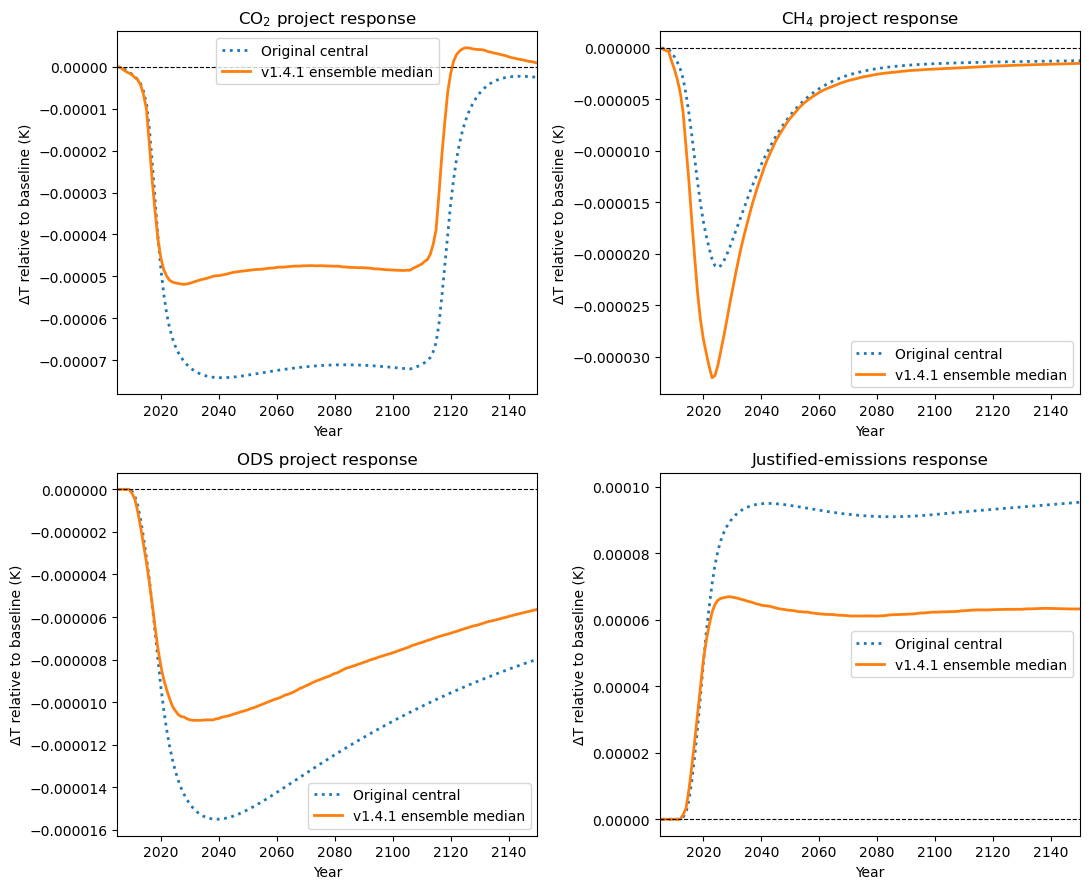

In [24]:
# ----------------------------
# plot old vs new component responses
# ----------------------------

old_base = f.temperature.sel(scenario=OLD_BASELINE_SCENARIO, config="central", layer=0)
old_co2 = (f.temperature.sel(scenario="actual_co2", config="central", layer=0) - old_base).values
old_ch4 = (f.temperature.sel(scenario="actual_ch4", config="central", layer=0) - old_base).values
old_ods = (f.temperature.sel(scenario="actual_ods", config="central", layer=0) - old_base).values
old_emissions_only = (f.temperature.sel(scenario="emissions_only", config="central", layer=0) - old_base).values

new_base = f_ens.temperature.sel(scenario=BASELINE_SCENARIO, layer=0)
new_co2 = (f_ens.temperature.sel(scenario="project_co2", layer=0) - new_base).median("config").values
new_ch4 = (f_ens.temperature.sel(scenario="project_ch4", layer=0) - new_base).median("config").values
new_ods = (f_ens.temperature.sel(scenario="project_ods", layer=0) - new_base).median("config").values

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

axes[0].plot(years, old_co2, ":", lw=2, label="Original central")
axes[0].plot(years, new_co2, lw=2, label="v1.4.1 ensemble median")
axes[0].set_title("CO$_2$ project response")

axes[1].plot(years, old_ch4, ":", lw=2, label="Original central")
axes[1].plot(years, new_ch4, lw=2, label="v1.4.1 ensemble median")
axes[1].set_title("CH$_4$ project response")

axes[2].plot(years, old_ods, ":", lw=2, label="Original central")
axes[2].plot(years, new_ods, lw=2, label="v1.4.1 ensemble median")
axes[2].set_title("ODS project response")

axes[3].plot(years, old_emissions_only, ":", lw=2, label="Original central")
axes[3].plot(years, emissions_only_central, lw=2, label="v1.4.1 ensemble median")
axes[3].set_title("Justified-emissions response")

for ax in axes:
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_xlim(2005, 2150)
    ax.set_xlabel("Year")
    ax.set_ylabel("ΔT relative to baseline (K)")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend()
plt.tight_layout()
plt.show()

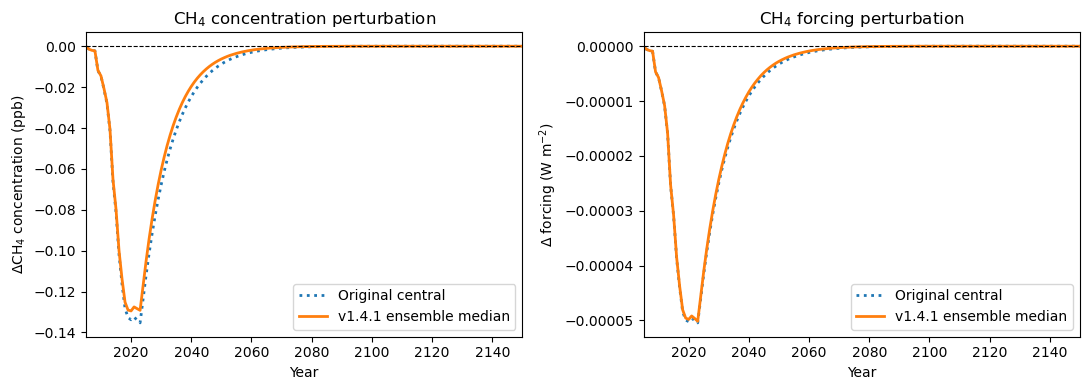

CH4 perturbation decay timescale: 8.74 years


In [25]:
# ----------------------------
# diagnose ch4 response changes between old and new model configurations
# ----------------------------

old_base_conc = f.concentration.sel(scenario=OLD_BASELINE_SCENARIO, config="central", specie="CH4")
old_ch4_conc = (f.concentration.sel(scenario="actual_ch4", config="central", specie="CH4") - old_base_conc).values

new_base_conc = f_ens.concentration.sel(scenario=BASELINE_SCENARIO, specie="CH4")
new_ch4_conc = f_ens.concentration.sel(scenario="project_ch4", specie="CH4") - new_base_conc
new_ch4_conc_median = new_ch4_conc.median("config").values

old_base_forcing = f.forcing.sel(scenario=OLD_BASELINE_SCENARIO, config="central", specie="CH4")
old_ch4_forcing = (f.forcing.sel(scenario="actual_ch4", config="central", specie="CH4") - old_base_forcing).values

new_base_forcing = f_ens.forcing.sel(scenario=BASELINE_SCENARIO, specie="CH4")
new_ch4_forcing = f_ens.forcing.sel(scenario="project_ch4", specie="CH4") - new_base_forcing
new_ch4_forcing_median = new_ch4_forcing.median("config").values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(years, old_ch4_conc, ":", lw=2, label="Original central")
axes[0].plot(years, new_ch4_conc_median, lw=2, label="v1.4.1 ensemble median")
axes[0].set_title("CH$_4$ concentration perturbation")
axes[0].set_ylabel("ΔCH$_4$ concentration (ppb)")

axes[1].plot(years, old_ch4_forcing, ":", lw=2, label="Original central")
axes[1].plot(years, new_ch4_forcing_median, lw=2, label="v1.4.1 ensemble median")
axes[1].set_title("CH$_4$ forcing perturbation")
axes[1].set_ylabel("Δ forcing (W m$^{-2}$)")

for ax in axes:
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_xlim(2005, 2150)
    ax.set_xlabel("Year")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend()

plt.tight_layout()
plt.show()

# fit an exponential to the declining CH4 concentration anomaly
# this estimates the marginal perturbation lifetime rather than the instantaneous atmospheric lifetime
dch4 = (f_ens.concentration.sel(scenario="project_ch4", specie="CH4") - f_ens.concentration.sel(scenario=BASELINE_SCENARIO, specie="CH4")).median("config").values

mask = (years >= 2025) & (years <= 2060) & (dch4 < 0)
coef = np.polyfit(years[mask], np.log(-dch4[mask]), 1)
tau_decay = -1 / coef[0]

print(f"CH4 perturbation decay timescale: {tau_decay:.2f} years")

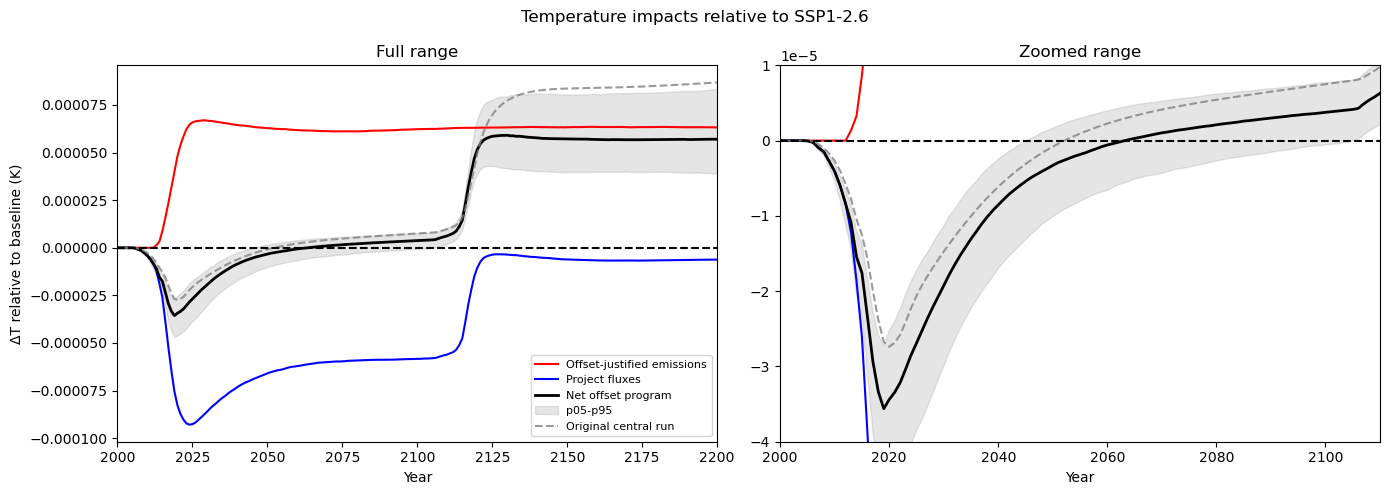

In [36]:
# plot net program temperature response with legacy model results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full view
axes[0].plot(years, emissions_only_central, color="red", label="Offset-justified emissions")
axes[0].plot(years, projects_only_central, color="blue", label="Project fluxes")
axes[0].plot(years, net_program_central, color="black", label="Net offset program", linewidth=2)
axes[0].fill_between(years, net_program_lower, net_program_upper,
                     color="gray", alpha=0.2, label="p05-p95")
axes[0].plot(years, net_program_old_central, linestyle="--", color="gray",
             alpha=0.8, label="Original central run")
axes[0].axhline(0, ls="--", color="k")
axes[0].set_xlim(2000, 2200)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("ΔT relative to baseline (K)")
axes[0].set_title("Full range")
axes[0].legend(fontsize=8)

# zoomed view
axes[1].plot(years, emissions_only_central, color="red", label="Offset-justified emissions")
axes[1].plot(years, projects_only_central, color="blue", label="Project fluxes")
axes[1].plot(years, net_program_central, color="black", label="Net offset program", linewidth=2)
axes[1].fill_between(years, net_program_lower, net_program_upper,
                     color="gray", alpha=0.2)
axes[1].plot(years, net_program_old_central, linestyle="--", color="gray",
             alpha=0.8, label="Original central run")

axes[1].axhline(0, ls="--", color="k")
axes[1].set_xlim(2000, 2110)
axes[1].set_ylim(-0.00004, 0.00001)
axes[1].set_xlabel("Year")
axes[1].set_title("Zoomed range")

fig.suptitle("Temperature impacts relative to SSP1-2.6")
plt.tight_layout()
plt.show()

In [27]:
# ----------------------------
# calculate crossover year and uncertainty
# ----------------------------

# We define the crossover year as the first year after 2025 in which the net temperature effect of the offset program changes from 
# cooling to warming relative to the no-offset SSP1-2.6 baseline. For each ensemble member, the crossover is calculated independently 
# from its paired net-program temperature trajectory, with linear interpolation between annual time steps.

def find_crossover(years, diff, min_year=2025):
    # ignore irrelevant early crossings
    mask = years >= min_year
    y = years[mask]
    d = np.asarray(diff)[mask]
    crossing_indices = np.where(np.diff(np.sign(d)) != 0)[0]
    if len(crossing_indices) == 0:
        return np.nan

    # use first crossover after min_year
    i = crossing_indices[0]
    return y[i] - d[i] * (y[i + 1] - y[i]) / (d[i + 1] - d[i])

# ensemble-median crossover
central_crossover = find_crossover(years, net_program_central )

# original central-run crossover
old_central_crossover = find_crossover(years, net_program_old_central)

# crossover for every ensemble member
ensemble_crossovers = []

for config in net_program_ensemble.config.values:
    diff = net_program_ensemble.sel(config=config).values
    ensemble_crossovers.append(find_crossover(years, diff))

ensemble_crossovers = np.asarray(ensemble_crossovers)
ensemble_crossovers = ensemble_crossovers[~np.isnan(ensemble_crossovers)]

crossover_median = np.median(ensemble_crossovers)
crossover_sd = np.std(ensemble_crossovers, ddof=1)

print(f"Ensemble median trajectory crossover: {central_crossover:.1f}")
print(f"Ensemble crossover distribution: {crossover_median:.1f} ± {crossover_sd:.1f} years (median ± SD)")
print(f"Original central run crossover: {old_central_crossover:.1f}")

Ensemble median trajectory crossover: 2063.2
Ensemble crossover distribution: 2063.2 ± 17.4 years (median ± SD)
Original central run crossover: 2052.1


The program as a whole eventually becomes net warming in 2075. In the subsequent sections, we explore how the following factors influence the crossover year:

1. The influence of each gas and it's GWP100 conversion influences the total program trajectory.
2. The choice of equivalency metric (what would have been different if gwp20, gtp50, gtp100, or like-for-like logic had been applied instead of gwp100?)
3. How coninued generation of CH4, ODS and CO2 credits would impact the eventual temperature crossover year.
4. How additionality issues in each type of credit impact the temperature trajectory and crossover year.

## 1. Impact of the gwp100 conversion

First, we compare the cooling affect of the actual portfolio of offset project fluxes versus the claimed cooling effect of an "equivalent" CO2 flux. We are not looking at net program trajectories to avoid assumptions about which credits went to CO2 vs N2O vs CH4 justified emissions. This exercise assumes project fluxes and CO2e justified emissions occur in the same year.

In [28]:
# extract updated ensemble temperature trajectories
years = np.asarray(f_ens.timebounds, dtype=float)
baseline = f_ens.temperature.sel(scenario=BASELINE_SCENARIO, layer=0)

actual = f_ens.temperature.sel(scenario="projects_only", layer=0) - baseline
claimed = f_ens.temperature.sel(scenario="claimed_project", layer=0) - baseline
actual_ch4_t = f_ens.temperature.sel(scenario="project_ch4", layer=0) - baseline
claimed_ch4_t = f_ens.temperature.sel(scenario="claimed_ch4", layer=0) - baseline
actual_ods_t = f_ens.temperature.sel(scenario="project_ods", layer=0) - baseline
claimed_ods_t = f_ens.temperature.sel(scenario="claimed_ods", layer=0) - baseline

actual_diff = actual.median("config").values
claimed_diff = claimed.median("config").values
actual_ch4_t = actual_ch4_t.median("config").values
claimed_ch4_t = claimed_ch4_t.median("config").values
actual_ods_t = actual_ods_t.median("config").values
claimed_ods_t = claimed_ods_t.median("config").values

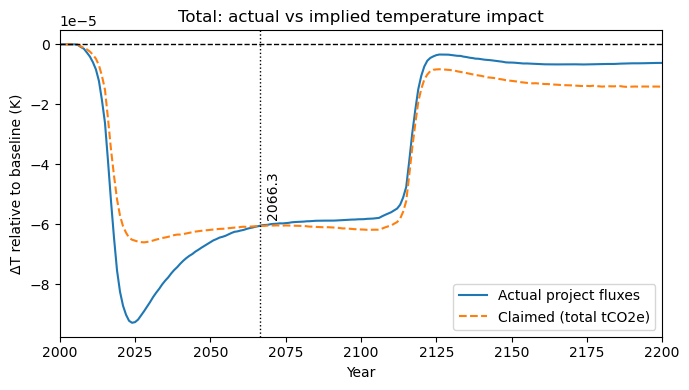

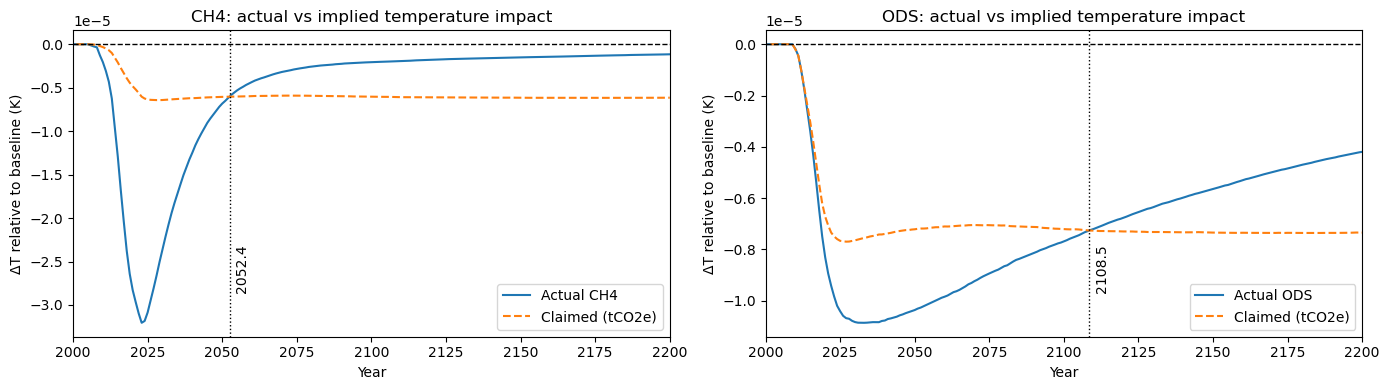

In [29]:
# calculate crossover years

#  ---  First, calculate total total  ---  
comparison_diff = actual_diff - claimed_diff

crossing_indices = np.where(np.diff(np.sign(comparison_diff)) != 0)[0]
crossing_indices = crossing_indices[years[crossing_indices] > 2010]

if len(crossing_indices) > 0:
    i = crossing_indices[0]
    crossover_year = years[i] - comparison_diff[i] * (years[i + 1] - years[i]) / (comparison_diff[i + 1] - comparison_diff[i])
else:
    crossover_year = np.nan

plt.figure(figsize=(7, 4))
plt.plot(years, actual_diff, label="Actual project fluxes")
plt.plot(years, claimed_diff, "--", label="Claimed (total tCO2e)")
plt.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(crossover_year):
    plt.axvline(crossover_year, linestyle=":", linewidth=1, color="k")
    plt.text(crossover_year + 2, plt.ylim()[0] * 0.6, f"{crossover_year:.1f}", rotation=90, va="bottom")

plt.xlim(2000, 2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Total: actual vs implied temperature impact")
plt.legend()
plt.tight_layout()
plt.show()

#  ---  Next, ODS and CH4-specific  ---  
ods_diff = actual_ods_t - claimed_ods_t
ods_crossing_indices = np.where(np.diff(np.sign(ods_diff)) != 0)[0]
ods_crossing_indices = ods_crossing_indices[years[ods_crossing_indices] > 2025]

if len(ods_crossing_indices) > 0:
    i = ods_crossing_indices[0]
    ods_crossover_year = years[i] - ods_diff[i] * (years[i + 1] - years[i]) / (ods_diff[i + 1] - ods_diff[i])
else:
    ods_crossover_year = np.nan

ch4_diff = actual_ch4_t - claimed_ch4_t
ch4_crossing_indices = np.where(np.diff(np.sign(ch4_diff)) != 0)[0]
ch4_crossing_indices = ch4_crossing_indices[years[ch4_crossing_indices] > 2025]

if len(ch4_crossing_indices) > 0:
    i = ch4_crossing_indices[0]
    ch4_crossover_year = years[i] - ch4_diff[i] * (years[i + 1] - years[i]) / (ch4_diff[i + 1] - ch4_diff[i])
else:
    ch4_crossover_year = np.nan

#   ---  plot temperature trajectories  ---  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ch4 temperature
ax1.plot(years, actual_ch4_t, label="Actual CH4")
ax1.plot(years, claimed_ch4_t, "--", label="Claimed (tCO2e)")
ax1.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(ch4_crossover_year):
    ax1.axvline(ch4_crossover_year, linestyle=":", linewidth=1, color="k")
    ax1.text(ch4_crossover_year + 2, ax1.get_ylim()[0] * 0.85, f"{ch4_crossover_year:.1f}", rotation=90, va="bottom")

ax1.set_xlim(2000, 2200)
ax1.set_xlabel("Year")
ax1.set_ylabel("ΔT relative to baseline (K)")
ax1.set_title("CH4: actual vs implied temperature impact")
ax1.legend()

# ods temperature
ax2.plot(years, actual_ods_t, label="Actual ODS")
ax2.plot(years, claimed_ods_t, "--", label="Claimed (tCO2e)")
ax2.axhline(0, linestyle="--", linewidth=1, color="k")

if not np.isnan(ods_crossover_year):
    ax2.axvline(ods_crossover_year, linestyle=":", linewidth=1, color="k")
    ax2.text(ods_crossover_year + 2, ax2.get_ylim()[0] * 0.85, f"{ods_crossover_year:.1f}", rotation=90, va="bottom")

ax2.set_xlim(2000, 2200)
ax2.set_xlabel("Year")
ax2.set_ylabel("ΔT relative to baseline (K)")
ax2.set_title("ODS: actual vs implied temperature impact")
ax2.legend()

plt.tight_layout()
plt.show()

Why the crossover year is different here than above: The claimed total CO2e trajectory treats all project credits as avoided CO2, but net program uses the actual justified emissions mix, which includes CO2, CH4 and N2O.

## 2. Impact of the equivalency metric choice

Here, we test how different equivalency metrics for coverting non-CO2 gases to CO2e flux and thus justified emissions impacts the temperature trajectory and crossover year of the program as a whole. In these experiments, we remove the temporary storage component of project fluxes so crossover year is not impacted by the release of the temporary CO2 credits. We assume that the added or removed credits from equivalency metric changes are proportionally distributed amongst justified CO2 fluxes. 

Equivalency metric runs: 100%|████████████████████| 6/6 [01:13<00:00, 12.22s/it]


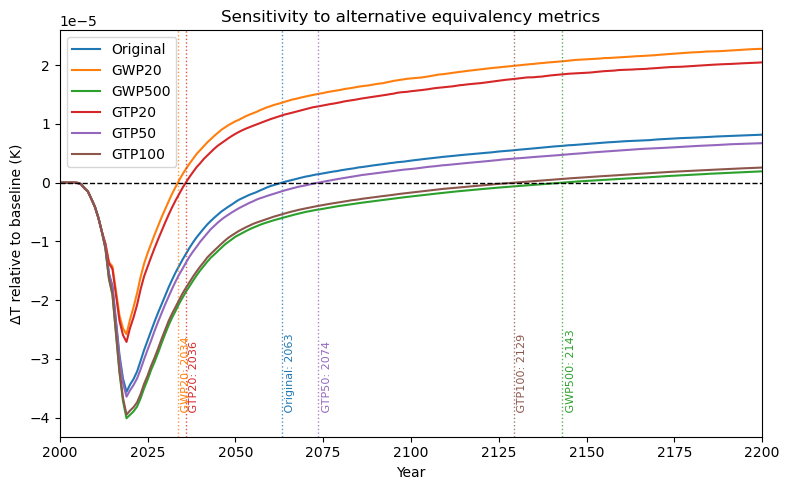

In [30]:
# Assume that all change in credits generated by using different equivalncey metrics is countered by a change in justified CO2 emissions
# Justified CH4 and N2O emissions RTS between scenarios because they make up <1% of total justified CO2e.

equiv_metrics = {
    "GWP20": {"ch4": 84, "ods": ODS_GWP20},
    "GWP500": {"ch4": 8, "ods": ODS_GWP500},
    "GTP20": {"ch4": 67, "ods": ODS_GTP20},
    "GTP50": {"ch4": 14, "ods": ODS_GTP50},
    "GTP100": {"ch4": 4, "ods": ODS_GTP100}}

def calculate_nonco2_co2e(df_p, ch4_values, ods_values):
    nonco2_co2e = df_p["ch4_flux"] * ch4_values
    for column, sp in ODS_COLUMN_TO_SPECIES.items():
        nonco2_co2e = nonco2_co2e + df_p[column] * ods_values[sp]
    return nonco2_co2e

def make_alt_justified_emissions(df_p, df_e, metric_values):
    df_alt = df_e.copy()

    # calculate original co2e using current program gwp100 assumptions
    project_co2e = df_p[["year", "ch4_flux", *ODS_COLUMNS]].copy()
    project_co2e["original_nonco2_co2e"] = calculate_nonco2_co2e(project_co2e, project_co2e["year"].apply(gwp_ch4), ODS_GWP100)

    # calculate alternative co2e using selected metric
    project_co2e["alt_nonco2_co2e"] = calculate_nonco2_co2e(project_co2e, metric_values["ch4"], metric_values["ods"])

    # difference in credited co2e relative to current accounting
    project_co2e["delta_co2e"] = project_co2e["alt_nonco2_co2e"] - project_co2e["original_nonco2_co2e"]
    delta_by_year = project_co2e.groupby("year")["delta_co2e"].sum().reset_index()

    # subtract the crediting difference from co2 justified emissions
    df_alt = df_alt.merge(delta_by_year, on="year", how="left")
    df_alt["delta_co2e"] = df_alt["delta_co2e"].fillna(0)
    df_alt["co2_justified"] = df_alt["co2_justified"] - df_alt["delta_co2e"]
    return df_alt.drop(columns="delta_co2e")

def run_program_fair(df_p, df_e_run, configs=None):
    run_configs = ensemble_configs if configs is None else configs
    f_run = FAIR(ch4_method="Thornhill2021")
    f_run.define_time(1750, 2200, 1)
    f_run.define_scenarios([BASELINE_SCENARIO, "net_program"])
    f_run.define_configs(run_configs)
    f_run.define_species(species_ens, properties_ens)
    f_run.allocate()

    # v1.4.1 calibrated/constrained ensemble
    f_run.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
    f_run.override_defaults(FAIR_PARAMS_FILE)

    # v1.4.0 methane lifetime treatment, matching primary analysis
    fill(f_run.species_configs["unperturbed_lifetime"], CH4_BASE_LIFETIME_YR, specie="CH4")
    fill(f_run.species_configs["lifetime_temperature_sensitivity"], ch4_v140["temp"])
    # fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["CH4"], specie="CH4") # Hughes et al., doesn't use this. 
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["N2O"], specie="N2O")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["HC"], specie="Equivalent effective stratospheric chlorine")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["NOx"], specie="NOx")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["VOC"], specie="VOC")

    fill(f_run.climate_configs["stochastic_run"], False)
    fill(f_run.climate_configs["use_seed"], False)

    # copy SSP1-2.6 background into both scenarios
    base_emissions = f_base.emissions.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_concentration = f_base.concentration.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_forcing = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central").values

    for scen in [BASELINE_SCENARIO, "net_program"]:
        f_run.emissions.loc[dict(scenario=scen)].values[:] = base_emissions[:, None, :]
        f_run.concentration.loc[dict(scenario=scen)].values[:] = base_concentration[:, None, :]
        f_run.forcing.loc[dict(scenario=scen)].values[:] = base_forcing[:, None, :]

    timepoints = np.asarray(f_run.timepoints, dtype=float)

    # project fluxes
    for _, row in df_p.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie="CO2 FFI")].values += row["co2_flux"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie="CH4")].values += row["ch4_flux"] / 1e6
        for column, sp in ODS_COLUMN_TO_SPECIES.items():
            f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie=sp)].values += row[column] / 1e3

    # justified emissions
    for _, row in df_e_run.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(row["year"])))]
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie="CO2 FFI")].values += row["co2_justified"] / 1e9
        f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie="CH4")].values += row["ch4_justified"] / 1e6
        if "n2o_justified" in df_e_run.columns:
            f_run.emissions.loc[dict(timepoints=yr, scenario="net_program", specie="N2O")].values += row["n2o_justified"] / 1e6

    # initialize exactly as in primary ensemble run
    initialise(f_run.concentration, f_run.species_configs["baseline_concentration"])
    initialise(f_run.forcing, 0.0)
    initialise(f_run.temperature, 0.0)
    initialise(f_run.cumulative_emissions, 0.0)
    initialise(f_run.airborne_emissions, 0.0)
    initialise(f_run.ocean_heat_content_change, 0.0)
    
    # restore SSP1-2.6 solar and volcanic forcing after initialization
    for scen in [BASELINE_SCENARIO, "net_program"]:
        for sp in ["Solar", "Volcanic"]:
            if sp in species_ens:
                base = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values[:, None]
                scale_col = f"forcing_scale[{sp}]"
                scales = (df_configs.loc[run_configs, scale_col].values
                    if scale_col in df_configs.columns
                    else np.ones(len(run_configs)))
                
                f_run.forcing.loc[dict(scenario=scen, specie=sp)].values[:] = base * scales[None, :]
    
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            f_run.run()

    years_run = np.asarray(f_run.timebounds, dtype=float)
    baseline_temp = f_run.temperature.sel(scenario=BASELINE_SCENARIO, layer=0)
    net_temp = f_run.temperature.sel(scenario="net_program", layer=0) - baseline_temp
    return years_run, net_temp.median("config").values

# exclude future temporary CO2 storage re-release
df_p_metric = df_p[df_p["year"] <= 2030].copy()

# run original and alternative metric cases
from tqdm.auto import tqdm
temp_results = {}
runs = [("Original", None)] + list(equiv_metrics.items())
for label, metric_values in tqdm(runs, desc="Equivalency metric runs"):
    if label == "Original":
        df_e_run = df_e
    else:
        df_e_run = make_alt_justified_emissions(df_p_metric, df_e, metric_values)
    years_sens, temp_results[label] = run_program_fair(df_p_metric, df_e_run)
    
#  ---  helper: find crossover year  --- 
def find_crossover_year(years, temp):
    years = np.asarray(years)
    temp = np.asarray(temp)

    # find first transition from negative to non-negative
    idx = np.where((temp[:-1] < 0) & (temp[1:] >= 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    
    # linearly interpolate between the two surrounding points
    x0, x1 = years[i], years[i + 1]
    y0, y1 = temp[i], temp[i + 1]
    return x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

#  ---  plot temperature trajectories with crossover years  --- 
plt.figure(figsize=(8, 5))
ax = plt.gca()

for label, temp in temp_results.items():
    line, = ax.plot(years_sens, temp, label=label)
    color = line.get_color()
    crossover_year = find_crossover_year(years_sens, temp)
    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)
        ax.text(crossover_year+1, 0.05, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=8, transform=ax.get_xaxis_transform())

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to alternative equivalency metrics")
ax.legend()
plt.tight_layout()
plt.show()

,Metric,Crossover year,CH4 credits (MtCO2e),CH4 credits (% of original),ODS credits (MtCO2e),ODS credits (% of original)
0,Original GWP100,2063.2,16.06,100.0,19.17,100.0
1,GWP20,2033.6,62.28,387.7,15.96,83.2
2,GWP500,2143.0,5.93,36.9,9.57,49.9
3,GTP20,2035.9,49.67,309.3,22.32,116.4
4,GTP50,2073.6,10.38,64.6,20.56,107.2
5,GTP100,2129.3,2.97,18.5,14.94,77.9


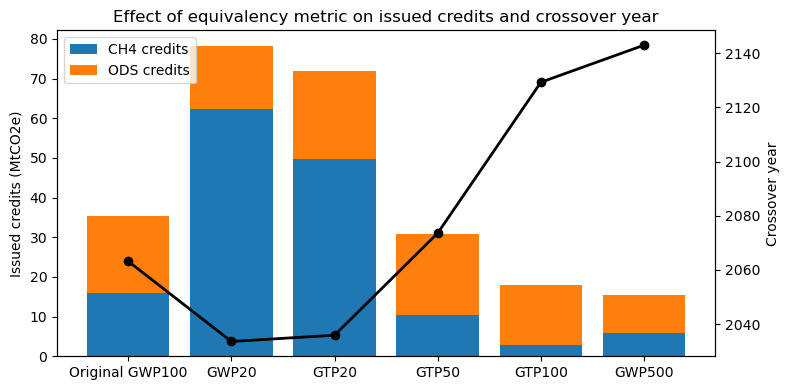

In [31]:
# ---- summarize equivalency metric results ----

equiv_summary = []

# use crediting period only to calculate issued credits
df_p_crediting = df_p[df_p["year"] <= 2025].copy()

# use crediting period only to calculate issued credits
df_p_crediting = df_p[df_p["year"] <= 2025].copy()

# original gwp100 credit totals
original_ch4_credits = -1 * (df_p_crediting["ch4_flux"] * df_p_crediting["year"].apply(gwp_ch4)).sum()
original_ods_credits = -1 * sum((df_p_crediting[column] * ODS_GWP100[sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())

equiv_summary.append({
    "metric": "Original GWP100",
    "ch4_metric": "current GWP100",
    "ods_metric": "gas-specific GWP100",
    "crossover_year": find_crossover_year(years_sens, temp_results["Original"]),
    "ch4_credits": original_ch4_credits,
    "ods_credits": original_ods_credits})

# alternative metric accounting
for metric_name, metric_values in equiv_metrics.items():
    ch4_credits = -1 * (df_p_crediting["ch4_flux"] * metric_values["ch4"]).sum()
    ods_credits = -1 * sum((df_p_crediting[column] * metric_values["ods"][sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())

    equiv_summary.append({
        "metric": metric_name,
        "ch4_metric": metric_values["ch4"],
        "ods_metric": "gas-specific",
        "crossover_year": find_crossover_year(years_sens, temp_results[metric_name]),
        "ch4_credits": ch4_credits,
        "ods_credits": ods_credits})

equiv_summary = pd.DataFrame(equiv_summary)
equiv_summary["crossover_year"] = equiv_summary["crossover_year"].round(1)
equiv_summary["ch4_credits_million"] = equiv_summary["ch4_credits"] / 1e6
equiv_summary["ods_credits_million"] = equiv_summary["ods_credits"] / 1e6
equiv_summary["ch4_credits_pct_original"] = 100 * equiv_summary["ch4_credits"] / original_ch4_credits
equiv_summary["ods_credits_pct_original"] = 100 * equiv_summary["ods_credits"] / original_ods_credits

display(equiv_summary[["metric", "crossover_year", "ch4_credits_million", "ch4_credits_pct_original", "ods_credits_million", "ods_credits_pct_original"]].rename(columns={
    "metric": "Metric",
    "crossover_year": "Crossover year",
    "ch4_credits_million": "CH4 credits (MtCO2e)",
    "ch4_credits_pct_original": "CH4 credits (% of original)",
    "ods_credits_million": "ODS credits (MtCO2e)",
    "ods_credits_pct_original": "ODS credits (% of original)"}).round({
        "Crossover year": 1,
        "CH4 credits (MtCO2e)": 2,
        "CH4 credits (% of original)": 1,
        "ODS credits (MtCO2e)": 2,
        "ODS credits (% of original)": 1}))

# ---- credits vs crossover year ----

plot_order = ["Original GWP100", "GWP20", "GTP20", "GTP50", "GTP100", "GWP500"]
plot_df = equiv_summary.set_index("metric").loc[plot_order].reset_index()

fig, ax1 = plt.subplots(figsize=(8, 4))
x = np.arange(len(plot_df))

# left axis: issued credits
ax1.bar(x, plot_df["ch4_credits_million"], label="CH4 credits")
ax1.bar(x, plot_df["ods_credits_million"], bottom=plot_df["ch4_credits_million"], label="ODS credits")
ax1.set_ylabel("Issued credits (MtCO2e)")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["metric"])
ax1.legend(loc="upper left")

# right axis: crossover year
ax2 = ax1.twinx()
ax2.plot(x, plot_df["crossover_year"], marker="o", linewidth=2, label="Crossover year", color="k")
ax2.set_ylabel("Crossover year")
ax1.set_title("Effect of equivalency metric on issued credits and crossover year")
plt.tight_layout()
plt.show()

## 3. Effect of Program Continuation

In this test, the program average CH4, ODS and Co2 project fluxes and corresponging jsutified CO2 emissions are calculated using 
CH4 and gas-specific ODS GWP100 values, then assume those project and justified fluxes continue for 200 years.

Assumptions: 
The release of temporary CO2 storage is ignored to assess SLCP temperature evolution. 
All future generated CH4 and ODS are used to justify CO2 emissions because jsutified N2O and CH4 justified emissions are small.

2010-2024 average CO2 project flux (tCO2/yr): -6142010.142857143
2010-2024 average CH4 project flux (tCH4/yr): -35304.426122448975
2010-2024 average CFC-11 project flux (tCFC-11/yr): -31.59095801550332
2010-2024 average CFC-12 project flux (tCFC-12/yr): -68.15750127961863
2010-2024 average CFC-113 project flux (tCFC-113/yr): -6.9193383925010705
2010-2024 average CFC-114 project flux (tCFC-114/yr): -3.1357486145166993
2010-2024 average CFC-115 project flux (tCFC-115/yr): -0.41747178003564106
2010-2024 average total CO2e credits (tCO2e/yr): 7937449.811918651


Program continuation runs: 100%|███████| 2/2 [00:25<00:00, 12.87s/it, Continued]


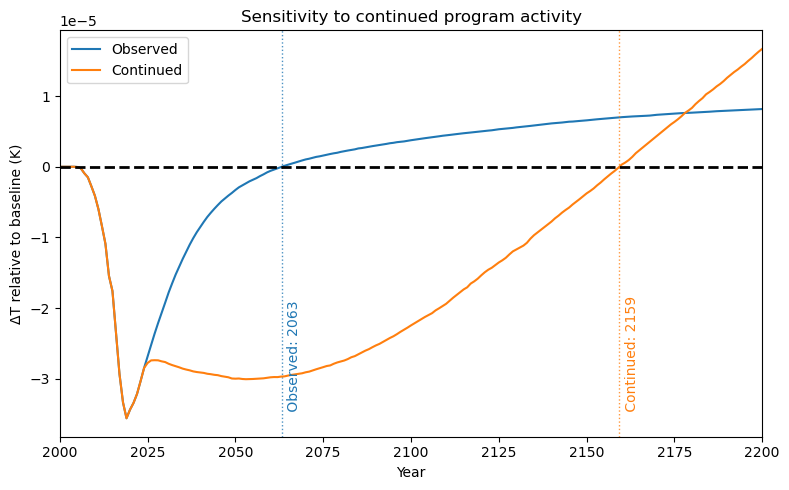

In [32]:
extension_start = 2025
extension_end = 2200

avg_window_start = 2005
avg_window_end = 2025

# ignore forest re-release rows after 2025
df_p_observed = df_p[df_p["year"] <= 2025].copy()

# calculate average annual project fluxes from 2010-2024
avg_project_fluxes = df_p_observed[(df_p_observed["year"] >= avg_window_start) & (df_p_observed["year"] <= avg_window_end)][["co2_flux", "ch4_flux", *ODS_COLUMNS]].mean()
avg_co2_flux = avg_project_fluxes["co2_flux"]
avg_ch4_flux = avg_project_fluxes["ch4_flux"]
avg_ods_fluxes = {column: avg_project_fluxes[column] for column in ODS_COLUMNS}

# convert average annual project fluxes to total co2e credits
avg_co2e_credits = -1 * (avg_co2_flux + avg_ch4_flux * 25 + sum(avg_ods_fluxes[column] * ODS_GWP100[sp] for column, sp in ODS_COLUMN_TO_SPECIES.items()))
print("2010-2024 average CO2 project flux (tCO2/yr):", avg_co2_flux)
print("2010-2024 average CH4 project flux (tCH4/yr):", avg_ch4_flux)
for column, sp in ODS_COLUMN_TO_SPECIES.items():
    print(f"2010-2024 average {sp} project flux (t{sp}/yr):", avg_ods_fluxes[column])
print("2010-2024 average total CO2e credits (tCO2e/yr):", avg_co2e_credits)

# create extension rows
extension_years = np.arange(extension_start, extension_end + 1)
df_p_extension = pd.DataFrame({"year": extension_years, "co2_flux": avg_co2_flux, "ch4_flux": avg_ch4_flux, **{column: avg_ods_fluxes[column] for column in ODS_COLUMNS}})
df_e_extension = pd.DataFrame({"year": extension_years, "co2_justified": avg_co2e_credits, "ch4_justified": 0, "n2o_justified": 0})

# combine observed and extended timeseries
df_p_continued = pd.concat([df_p_observed[df_p_observed["year"] < extension_start], df_p_extension], ignore_index=True).sort_values("year").fillna(0)
df_e_continued = pd.concat([df_e[df_e["year"] < extension_start], df_e_extension], ignore_index=True).sort_values("year")

# run observed and continued-program cases
from tqdm.auto import tqdm

continued_results = {}
runs = [
    ("Observed", df_p_observed, df_e),
    ("Continued", df_p_continued, df_e_continued)
]

pbar = tqdm(runs, desc="Program continuation runs")

for label, df_p_run, df_e_run in pbar:
    pbar.set_postfix_str(label)
    years_run, continued_results[label] = run_program_fair(df_p_run, df_e_run)

years_observed = years_run
temp_observed = continued_results["Observed"]
temp_continued = continued_results["Continued"]

#  --- plot with crossover years  --- 
continued_results = {
    "Observed": temp_observed,
    "Continued": temp_continued}
plt.figure(figsize=(8, 5))
ax = plt.gca()
for label, temp in continued_results.items():
    line, = ax.plot(years_observed, temp, label=label)
    color = line.get_color()
    crossover_year = find_crossover_year(years_observed, temp)
    if not np.isnan(crossover_year):
        ax.axvline(crossover_year, linestyle=":", linewidth=1, color=color, alpha=0.8)
        ax.text(crossover_year + 1.5, 0.05, f" {label}: {crossover_year:.0f}", color=color, rotation=90, va="bottom", ha="left", fontsize=10, transform=ax.get_xaxis_transform())

ax.axhline(0, linestyle="--", linewidth=2, color="k")
ax.set_xlim(2000, 2200)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Sensitivity to continued program activity")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Effect of Non-Additionality

Here, we test how the crossover point is impacted by some proportion of either CO2, CH4, or ODS project fluxes characterized as non-additional. For example, for non-additional CH4 credits, project CH4 fluxes are lowered but justified emissions of all gases remains the same.

Representative ensemble config: 1485320
Total CO2 credits: 128982213.0
Total CH4 credits: 16061514.0
Total ODS credits: 19169409.336005956


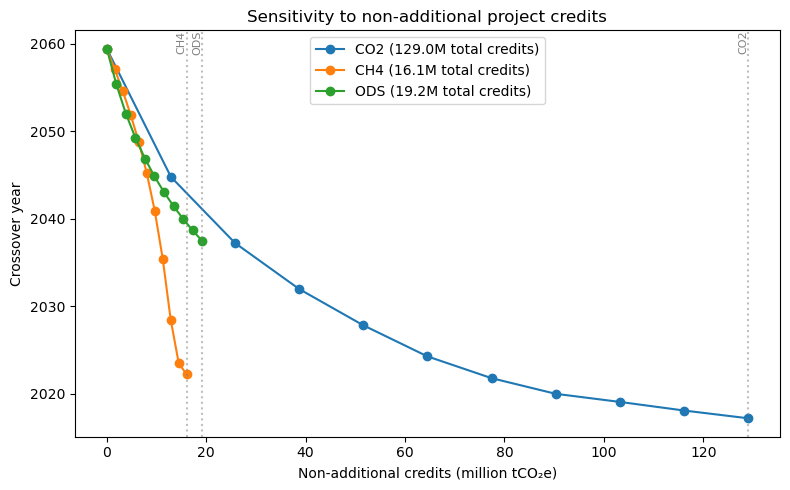

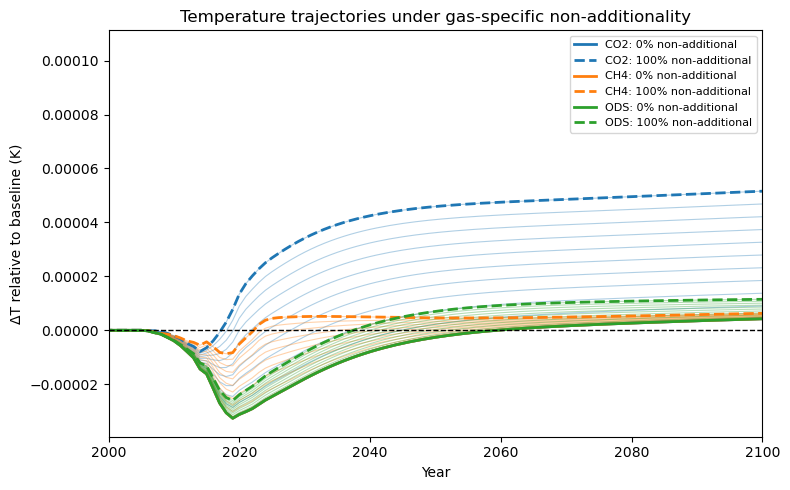

In [33]:
# choose calibrated ensemble member closest to the median net-program trajectory
target = net_program_ensemble.median("config")
rmse = np.sqrt(((net_program_ensemble - target) ** 2).mean("timebounds"))
central_config = df_configs.index[np.argmin(rmse.values)]

print("Representative ensemble config:", central_config)

# use crediting period only to calculate issued credits
df_p_crediting = df_p[df_p["year"] <= 2025].copy()
credit_totals = {
    "CO2": -1 * df_p_crediting["co2_flux"].sum(),
    "CH4": -1 * (df_p_crediting["ch4_flux"] * df_p_crediting["year"].apply(gwp_ch4)).sum(),
    "ODS": -1 * sum((df_p_crediting[column] * ODS_GWP100[sp]).sum() for column, sp in ODS_COLUMN_TO_SPECIES.items())}
nonadd_results = []
nonadd_trajectories = []

for gas, total_credits in credit_totals.items():
    credit_steps = np.linspace(0, total_credits, 11)
    for nonadd_credits in credit_steps:
        frac_nonadd = nonadd_credits / total_credits

        # use full project time series so 2110 re-emission is retained
        df_p_test = df_p.copy()

        # only reduce project benefits during the crediting period
        crediting_mask = df_p_test["year"] <= 2025
        if gas == "CO2":
            df_p_test.loc[crediting_mask, "co2_flux"] = df_p_test.loc[crediting_mask, "co2_flux"] * (1 - frac_nonadd)
        elif gas == "CH4":
            df_p_test.loc[crediting_mask, "ch4_flux"] = df_p_test.loc[crediting_mask, "ch4_flux"] * (1 - frac_nonadd)
        elif gas == "ODS":
            for column in ODS_COLUMNS:
                df_p_test.loc[crediting_mask, column] = df_p_test.loc[crediting_mask, column] * (1 - frac_nonadd)
        years_test, temp_test = run_program_fair(df_p_test, df_e, configs=[central_config])
        crossover_year = find_crossover_year(years_test, temp_test)
        nonadd_trajectories.append({"gas": gas, "nonadd_credits": nonadd_credits, "frac_nonadd": frac_nonadd, "years": years_test, "temp": temp_test})
        nonadd_results.append({"gas": gas, "nonadd_credits": nonadd_credits, "frac_nonadd": frac_nonadd, "crossover_year": crossover_year})

nonadd_results = pd.DataFrame(nonadd_results)
print("Total CO2 credits:", credit_totals["CO2"])
print("Total CH4 credits:", credit_totals["CH4"])
print("Total ODS credits:", credit_totals["ODS"])

#  --- plot crossover year vs absolute non-additional credits  --- 
plt.figure(figsize=(8, 5))
ax = plt.gca()
for gas in ["CO2", "CH4", "ODS"]:
    plot_df = nonadd_results[nonadd_results["gas"] == gas]
    ax.plot(plot_df["nonadd_credits"] / 1e6, plot_df["crossover_year"], marker="o", label=f"{gas} ({credit_totals[gas] / 1e6:.1f}M total credits)")
for gas in ["CO2", "CH4", "ODS"]:
    ax.axvline(credit_totals[gas] / 1e6, linestyle=":", alpha=0.5, color="gray")
    ax.text(credit_totals[gas] / 1e6, ax.get_ylim()[1], gas, rotation=90, va="top", ha="right", fontsize=8, color="gray")
ax.set_xlabel("Non-additional credits (million tCO₂e)")
ax.set_ylabel("Crossover year")
ax.set_title("Sensitivity to non-additional project credits")
ax.legend()
plt.tight_layout()
plt.show()

#  ---  plot temperature trajectories for all non-additionality scenarios  --- 
colors = {
    "CO2": "tab:blue",
    "CH4": "tab:orange",
    "ODS": "tab:green"}
plt.figure(figsize=(8, 5))
ax = plt.gca()
for result in nonadd_trajectories:
    ax.plot(result["years"], result["temp"], color=colors[result["gas"]], linewidth=0.8, alpha=0.35)
for gas in ["CO2", "CH4", "ODS"]:
    gas_results = [r for r in nonadd_trajectories if r["gas"] == gas]
    zero_nonadd = min(gas_results, key=lambda x: x["frac_nonadd"])
    full_nonadd = max(gas_results, key=lambda x: x["frac_nonadd"])
    ax.plot(zero_nonadd["years"], zero_nonadd["temp"], color=colors[gas], linewidth=2, label=f"{gas}: 0% non-additional")
    ax.plot(full_nonadd["years"], full_nonadd["temp"], color=colors[gas], linewidth=2, linestyle="--", label=f"{gas}: 100% non-additional")

ax.axhline(0, linestyle="--", linewidth=1, color="k")
ax.set_xlim(2000, 2100)
ax.set_xlabel("Year")
ax.set_ylabel("ΔT relative to baseline (K)")
ax.set_title("Temperature trajectories under gas-specific non-additionality")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

When crossover timing is plotted against absolute CO2e credits (figure 2), CH4 and ODS non-additionality appear more sensitive per credit (steeper slope).

It is important to note that these crossover sensitivities are partly shaped by the temperature trajectory of the full program, because each gas-specific perturbation is evaluated against the same combined project and justified-emissions baseline. Sensitivities likely differ in different contexts. 